In [1]:
import sys
sys.path.append('../../my_spatial_analyze/data_analyze/basin_wise_analysis')
sys.path.append('../../my_spatial_analyze/data_analyze/correlation_analysis')
import correlation_plots
import basin_wise_analysis
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import pandas as pd
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib as mpl
import geopandas as gpd
import numpy as np
from datetime import datetime
from dateutil.relativedelta import relativedelta


# make pdf editable in adobe illustrator
mpl.rcParams['pdf.fonttype'] = 42

Initializing pandarallel...
INFO: Pandarallel will run on 12 workers.
INFO: Pandarallel will use standard multiprocessing data transfer (pipe) to transfer data between the main process and workers.


In [2]:
hydrobasins_gdf_path = '/data/v2/hydrobasins_lev02_with_statistics_with_missing_data_count_and_area_full_quarter.pkl'
hydrobasins_gdf = pd.read_pickle(hydrobasins_gdf_path)
# simplify the hydrobasins_gdf
hydrobasins_gdf.geometry = hydrobasins_gdf.geometry.simplify(tolerance=0.1)

start_date = '2001-01-01'
end_date = '2022-01-01'
date_fmt = '%Y-%m-%d'
start_date = datetime.strptime(start_date, date_fmt)
end_date = datetime.strptime(end_date, date_fmt)
common_area_columns = []
current_date = start_date
while current_date < end_date:
    current_date_str = current_date.strftime(date_fmt)
    common_area_columns.append(current_date_str)
    current_date += relativedelta(months=1)
    
gsw_missing_area_columns = [f'gsw_missing_area_{date_str}' for date_str in common_area_columns]
my_missing_area_columns = [f'my_missing_area_{date_str}' for date_str in common_area_columns]

gsw_missing_count_columns = [f'gsw_missing_count_{date_str}' for date_str in common_area_columns]
my_missing_count_columns = [f'my_missing_count_{date_str}' for date_str in common_area_columns]

total_area_columns = [f'lake_total_boundary_area_{date_str}' for date_str in common_area_columns]
total_count_columns = [f'lake_count_{date_str}' for date_str in common_area_columns]

gsw_missing_area_array = np.array(hydrobasins_gdf[gsw_missing_area_columns])
my_missing_area_array = np.array(hydrobasins_gdf[my_missing_area_columns])

gsw_missing_count_array = np.array(hydrobasins_gdf[gsw_missing_count_columns])
my_missing_count_array = np.array(hydrobasins_gdf[my_missing_count_columns])

total_area_array = np.array(hydrobasins_gdf[total_area_columns])
total_count_array = np.array(hydrobasins_gdf[total_count_columns])


0.33880842
0.011714855
0.5982834500074923
0.017948613797654923


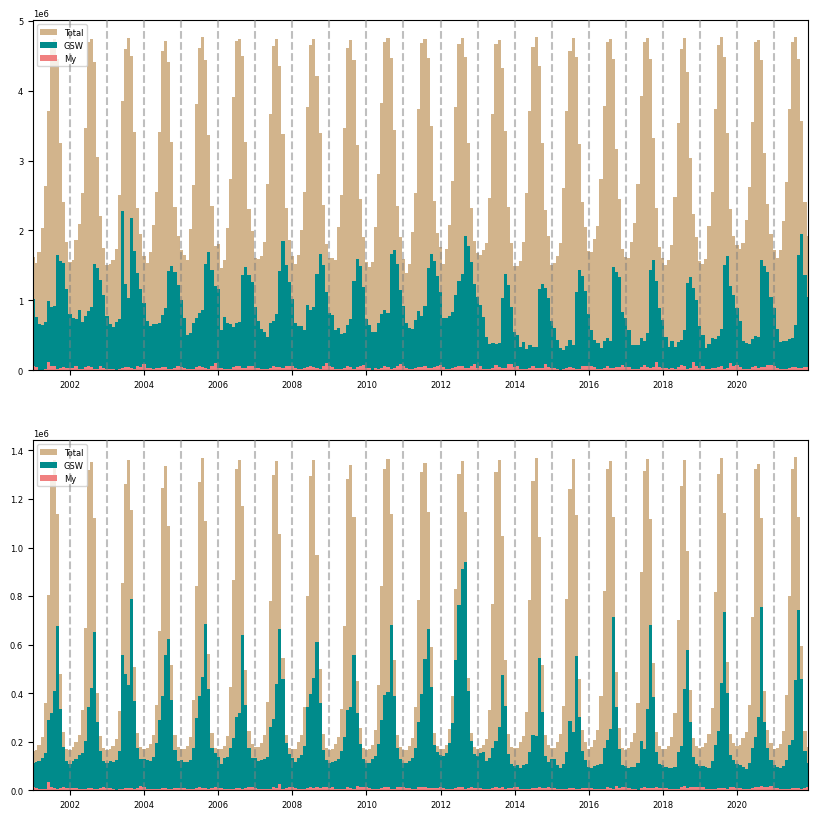

In [3]:
global_gsw_missing_area = np.sum(gsw_missing_area_array, axis=0)
global_my_missing_area = np.sum(my_missing_area_array, axis=0)

global_gsw_missing_count = np.sum(gsw_missing_count_array, axis=0)
global_my_missing_count = np.sum(my_missing_count_array, axis=0)

global_total_area = np.sum(total_area_array, axis=0)
global_total_count = np.sum(total_count_array, axis=0)

dates = pd.date_range(start=start_date, end=end_date, freq='MS', inclusive='left')
day_in_month = dates.days_in_month

fig, ax = plt.subplots(2, 1, figsize=(10, 10))
ax[0].bar(dates, global_total_area, color='tan', label='Total', width=31)
ax[0].bar(dates, global_gsw_missing_area, color='darkcyan', label='GSW', width=31)
ax[0].bar(dates, global_my_missing_area, color='lightcoral', label='My', width=31)
ax[0].legend()
ax[1].bar(dates, global_total_count, color='tan', label='Total', width=31)
ax[1].bar(dates, global_gsw_missing_count, color='darkcyan', label='GSW', width=31)
ax[1].bar(dates, global_my_missing_count, color='lightcoral', label='My', width=31)
ax[1].legend()
#ax[0].set_ylim(0, 1)
ax[0].set_xlim(pd.Timestamp('2001-01-01'), pd.Timestamp('2021-12-01'))
#ax[1].set_ylim(0, 1)
ax[1].set_xlim(pd.Timestamp('2001-01-01'), pd.Timestamp('2021-12-01'))

print(np.median(global_gsw_missing_area/global_total_area))
print(np.median(global_my_missing_area/global_total_area))
print(np.median(global_gsw_missing_count/global_total_count))
print(np.median(global_my_missing_count/global_total_count))

#for each year, add a vertical line to indicate the start of the year
for year in range(2002, 2022):
    ax[0].axvline(pd.Timestamp(f'{year}-01-01'), color='gray', linestyle='--', alpha=0.5, zorder=10)
    ax[1].axvline(pd.Timestamp(f'{year}-01-01'), color='gray', linestyle='--', alpha=0.5, zorder=10)

plt.savefig('/results/Ext_Data_Fig_10ab_raw.pdf', bbox_inches='tight')

/usr/local/lib/python3.8/dist-packages/geopandas/geodataframe.py:1538: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)
/usr/local/lib/python3.8/dist-packages/geopandas/geodataframe.py:1538: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)


0.4053825505232165
0.012997178830426552


/tmp/ipykernel_598/151452966.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  metric_df_my_missing_area['metric_type'] = 2
/tmp/ipykernel_598/151452966.py:51: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  metric_df_gsw_missing_area['metric_type'] = 1


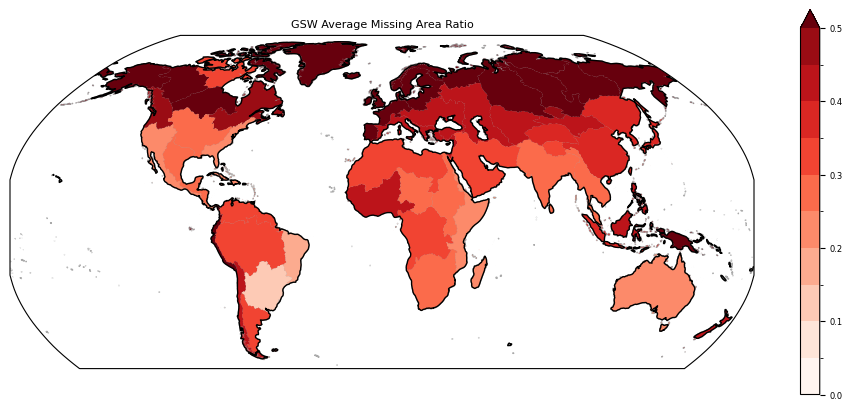

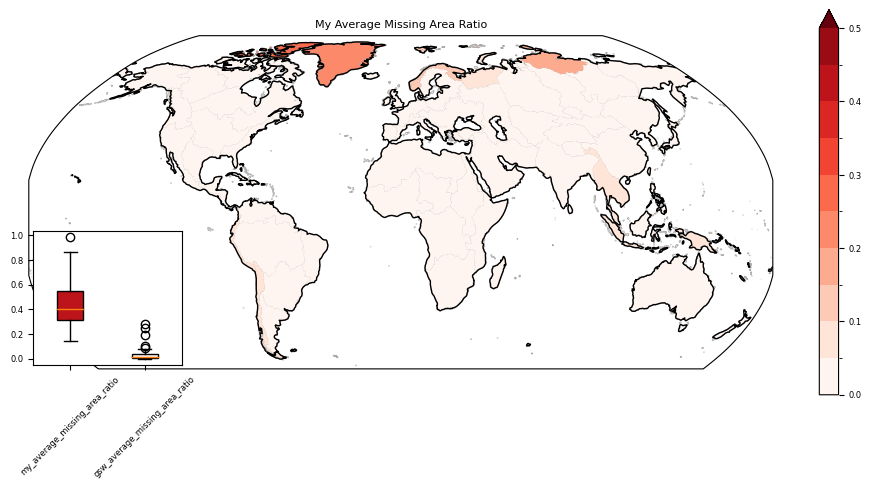

In [4]:
hydrobasins_gdf['gsw_average_missing_area_ratio'] = hydrobasins_gdf.apply(lambda row: np.mean(row[gsw_missing_area_columns].to_numpy()/row[total_area_columns].to_numpy()), axis=1)
hydrobasins_gdf['my_average_missing_area_ratio'] = hydrobasins_gdf.apply(lambda row: np.mean(row[my_missing_area_columns].to_numpy()/row[total_area_columns].to_numpy()), axis=1)

print(np.median(hydrobasins_gdf['gsw_average_missing_area_ratio']))
print(np.median(hydrobasins_gdf['my_average_missing_area_ratio']))

ax, sm = basin_wise_analysis.plot_hydrobasins_map_new(
    hydrobasins_gdf=hydrobasins_gdf,
    column_to_plot='gsw_average_missing_area_ratio',
    title='GSW Average Missing Area Ratio',
    use_discrete_color=True,
    discrete_bins=[0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5],
    cmap='Reds',
    edgecolor='none',
    vmin=0.0,
    vmax=0.5,
    add_rivers=False,
    projection=ccrs.Robinson(),
    extent=[-180, -60, 180, 90],
    set_global=False,
    gridlines=False,
    return_colorbar_sm=True,
    cbar_extend='max'
)

plt.savefig('/results/Ext_Data_Fig_10c_raw.pdf', bbox_inches='tight')

ax, sm = basin_wise_analysis.plot_hydrobasins_map_new(
    hydrobasins_gdf=hydrobasins_gdf,
    column_to_plot='my_average_missing_area_ratio',
    title='My Average Missing Area Ratio',
    use_discrete_color=True,
    discrete_bins=[0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5],
    cmap='Reds',
    edgecolor='none',
    vmin=0.0,
    vmax=0.5,
    add_rivers=False,
    projection=ccrs.Robinson(),
    extent=[-180, -60, 180, 90],
    set_global=False,
    gridlines=False,
    return_colorbar_sm=True,
    cbar_extend='max'
)

metric_df_my_missing_area = hydrobasins_gdf[['HYBAS_ID', 'my_average_missing_area_ratio']]
metric_df_my_missing_area['metric_type'] = 2
metric_df_my_missing_area = metric_df_my_missing_area.rename(columns={'my_average_missing_area_ratio': 'metric_name'})
metric_df_gsw_missing_area = hydrobasins_gdf[['HYBAS_ID', 'gsw_average_missing_area_ratio']]
metric_df_gsw_missing_area['metric_type'] = 1
metric_df_gsw_missing_area = metric_df_gsw_missing_area.rename(columns={'gsw_average_missing_area_ratio': 'metric_name'})
metric_df = pd.concat([metric_df_my_missing_area, metric_df_gsw_missing_area])

ax_for_box = inset_axes(ax, width="20%", height="40%", loc='lower left')
correlation_plots.box_plot_of_different_groups(
    to_plot_df=metric_df,
    to_plot_column_name='metric_name',
    to_group_by_column_name='metric_type',
    group_bins=[0, 1, 2],
    group_labels=['my_average_missing_area_ratio', 'gsw_average_missing_area_ratio'],
    show_fliers=True,
    ax=ax_for_box,
    group_colors_box=sm,
    show_plot=False,
)

plt.savefig('/results/Ext_Data_Fig_10d_raw.pdf', bbox_inches='tight')


/usr/local/lib/python3.8/dist-packages/geopandas/geodataframe.py:1538: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)
/usr/local/lib/python3.8/dist-packages/geopandas/geodataframe.py:1538: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)


0.6413375266569639
0.016990697915937106


/tmp/ipykernel_598/2286989474.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  metric_df_my_missing_count['metric_type'] = 2
/tmp/ipykernel_598/2286989474.py:51: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  metric_df_gsw_missing_count['metric_type'] = 1


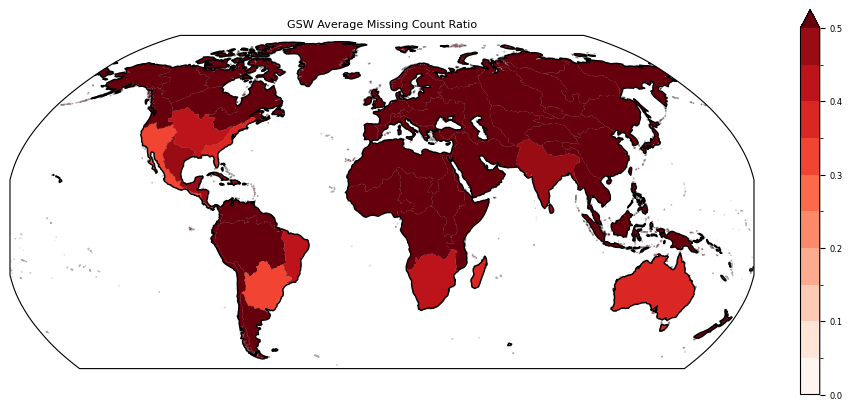

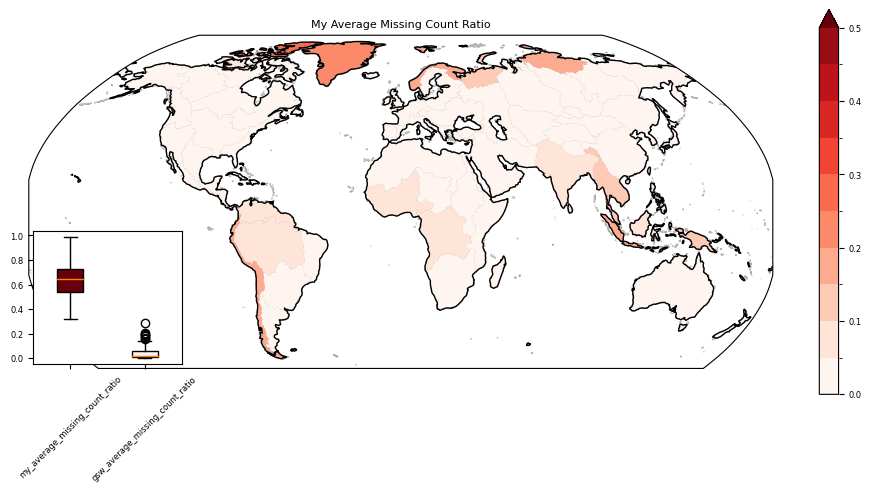

In [5]:
hydrobasins_gdf['gsw_average_missing_count_ratio'] = hydrobasins_gdf.apply(lambda row: np.mean(row[gsw_missing_count_columns].to_numpy()/row[total_count_columns].to_numpy()), axis=1)
hydrobasins_gdf['my_average_missing_count_ratio'] = hydrobasins_gdf.apply(lambda row: np.mean(row[my_missing_count_columns].to_numpy()/row[total_count_columns].to_numpy()), axis=1)

print(np.median(hydrobasins_gdf['gsw_average_missing_count_ratio']))
print(np.median(hydrobasins_gdf['my_average_missing_count_ratio']))

ax, sm = basin_wise_analysis.plot_hydrobasins_map_new(
    hydrobasins_gdf=hydrobasins_gdf,
    column_to_plot='gsw_average_missing_count_ratio',
    title='GSW Average Missing Count Ratio',
    use_discrete_color=True,
    discrete_bins=[0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5],
    cmap='Reds',
    edgecolor='none',
    vmin=0.0,
    vmax=0.5,
    add_rivers=False,
    projection=ccrs.Robinson(),
    extent=[-180, -60, 180, 90],
    set_global=False,
    gridlines=False,
    return_colorbar_sm=True,
    cbar_extend='max'
)

plt.savefig('/results/Ext_Data_Fig_10e_raw.pdf', bbox_inches='tight')

ax, sm = basin_wise_analysis.plot_hydrobasins_map_new(
    hydrobasins_gdf=hydrobasins_gdf,
    column_to_plot='my_average_missing_count_ratio',
    title='My Average Missing Count Ratio',
    use_discrete_color=True,
    discrete_bins=[0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5],
    cmap='Reds',
    edgecolor='none',
    vmin=0.0,
    vmax=0.5,
    add_rivers=False,
    projection=ccrs.Robinson(),
    extent=[-180, -60, 180, 90],
    set_global=False,
    gridlines=False,
    return_colorbar_sm=True,
    cbar_extend='max'
)

metric_df_my_missing_count = hydrobasins_gdf[['HYBAS_ID', 'my_average_missing_count_ratio']]
metric_df_my_missing_count['metric_type'] = 2
metric_df_my_missing_count = metric_df_my_missing_count.rename(columns={'my_average_missing_count_ratio': 'metric_name'})
metric_df_gsw_missing_count = hydrobasins_gdf[['HYBAS_ID', 'gsw_average_missing_count_ratio']]
metric_df_gsw_missing_count['metric_type'] = 1
metric_df_gsw_missing_count = metric_df_gsw_missing_count.rename(columns={'gsw_average_missing_count_ratio': 'metric_name'})
metric_df = pd.concat([metric_df_my_missing_count, metric_df_gsw_missing_count])

ax_for_box = inset_axes(ax, width="20%", height="40%", loc='lower left')
correlation_plots.box_plot_of_different_groups(
    to_plot_df=metric_df,
    to_plot_column_name='metric_name',
    to_group_by_column_name='metric_type',
    group_bins=[0, 1, 2],
    group_labels=['my_average_missing_count_ratio', 'gsw_average_missing_count_ratio'],
    show_fliers=True,
    ax=ax_for_box,
    group_colors_box=sm,
    show_plot=False,
)

plt.savefig('/results/Ext_Data_Fig_10f_raw.pdf', bbox_inches='tight')

In [7]:
print(hydrobasins_gdf['gsw_average_missing_count_ratio'].describe())
print(hydrobasins_gdf['my_average_missing_count_ratio'].describe())

count    60.000000
mean      0.632834
std       0.147240
min       0.319359
25%       0.537937
50%       0.641338
75%       0.726006
max       0.986412
Name: gsw_average_missing_count_ratio, dtype: float64
count    60.000000
mean      0.047185
std       0.064269
min       0.000813
25%       0.008353
50%       0.016991
75%       0.062841
max       0.285458
Name: my_average_missing_count_ratio, dtype: float64
